In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv("data/raw/creditcard.csv")

X = df.drop('Class', axis=1)

y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
print(X_train.shape)
print(X_test.shape)

(227845, 30)
(56962, 30)


### Train Logistic Regression Model

In [7]:
model = LogisticRegression(max_iter=6000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",6000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

### Observation
A Logistic Regression classifier was trained as a baseline model for fraud detection.

In [8]:
### Generate Predictions

y_pred = model.predict(X_test)



### Observation

Predictions were generated for unseen transactions in the testing dataset.

### Classification Report

In [10]:

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.91      0.83      0.86     56962
weighted avg       1.00      1.00      1.00     56962



### Observation
The Logistic Regression model achieved high overall accuracy due to the strong class imbalance in the dataset. For the fraud class, the model obtained a precision of 82%, indicating that most transactions flagged as fraudulent were correctly identified. However, the recall of 65% shows that approximately 35% of fraudulent transactions were missed. Since detecting fraud is the primary objective, improving recall will be an important focus in subsequent modeling stages.

### Confusion Matrix

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

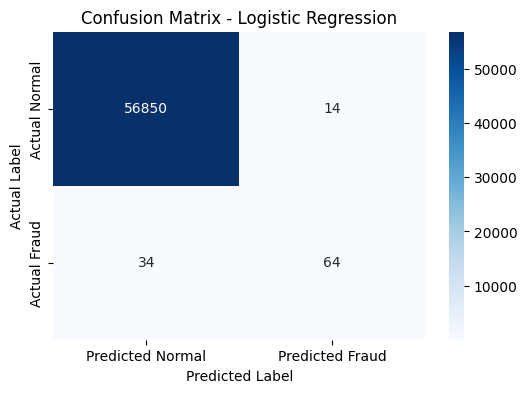

In [13]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Normal', 'Predicted Fraud'],
    yticklabels=['Actual Normal', 'Actual Fraud']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()


### Observation
The confusion matrix shows that the Logistic Regression model correctly classified 56,850 legitimate transactions and 64 fraudulent transactions. Only 14 legitimate transactions were incorrectly flagged as fraud, indicating a low false positive rate. However, the model failed to detect 34 fraudulent transactions, resulting in false negatives. Since missed fraud cases can lead to financial losses, improving fraud detection recall will be an important objective in future models.

### ROC-AUC Score

In [31]:
from sklearn.metrics import( roc_auc_score, roc_curve )

y_prob = model.predict_proba(X_test)[:,1]
auc_score = roc_auc_score(y_test, y_prob)
print("auc_score:", auc_score)


auc_score: 0.9524779136471697


### Observation
The Logistic Regression model achieved a ROC-AUC score of 0.9525, indicating excellent discrimination between fraudulent and legitimate transactions. This suggests that the model effectively ranks fraudulent transactions higher than legitimate ones. Despite the class imbalance, the model demonstrates strong predictive capability and provides a solid baseline for comparison with more advanced algorithms.

### ROC Curve



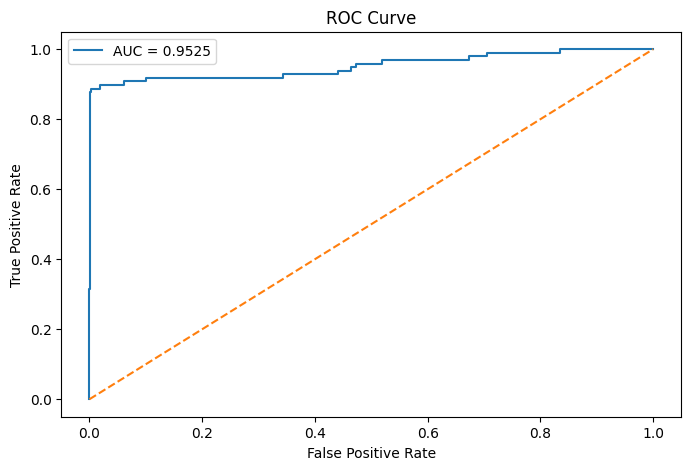

In [32]:
fpr , tpr , threshols = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,5))
plt.plot(fpr , tpr, label=f"AUC = {auc_score:.4f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

###
The ROC curve lies significantly above the random-classification line and remains close to the top-left corner of the plot. This indicates that the Logistic Regression model has a strong ability to distinguish between fraudulent and legitimate transactions. The ROC-AUC score of 0.9525 confirms excellent classification performance and suggests that the model effectively ranks fraudulent transactions higher than legitimate transactions across a wide range of classification thresholds.